A-matrix: 
 [[ 2.  -0.5  0.  ...  0.   0.   0. ]
 [-0.5  1.  -0.5 ...  0.   0.   0. ]
 [ 0.  -0.5  2.  ...  0.   0.   0. ]
 ...
 [ 0.   0.   0.  ...  2.   0.  -0.5]
 [ 0.   0.   0.  ...  0.   2.  -0.5]
 [ 0.   0.   0.  ... -0.5 -0.5  1. ]]
[0.00203451 0.00030924 0.00203451 0.00667318 0.00333659 0.00333659
 0.00911458 0.00911458 0.00415039 0.00415039 0.01057943 0.01155599
 0.01057943 0.00447591 0.00447591 0.01106771 0.01302083 0.01302083
 0.01106771 0.00431315 0.00431315 0.01057943 0.01350911 0.01448568
 0.01350911 0.01057943 0.00366211 0.00366211 0.00911458 0.01302083
 0.01497396 0.01497396 0.01302083 0.00911458 0.00252279 0.00252279
 0.00667318 0.01155599 0.01448568 0.01546224 0.01448568 0.01155599
 0.00667318 0.00091146 0.00091146 0.00252279 0.00911458 0.01302083
 0.01497396 0.01497396 0.01302083 0.00911458 0.00252279 0.00366211
 0.01057943 0.01350911 0.01448568 0.01350911 0.01057943 0.00366211
 0.00431315 0.01106771 0.01302083 0.01302083 0.01106771 0.00431315
 0.00447591 0.01057943 

/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


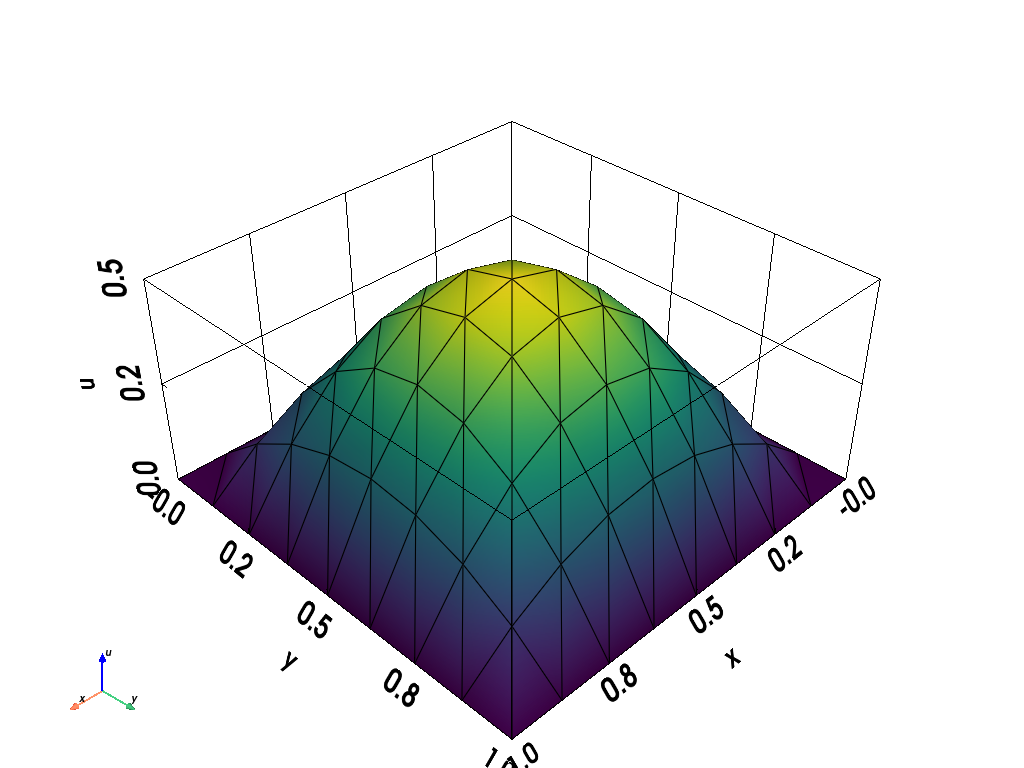

In [ ]:
# Fix MPI/OFI finalization errors on macOS
import os

os.environ["FI_PROVIDER"] = "tcp"
os.environ["MPICH_OFI_STARTUP_CONNECT"] = "0"


from mpi4py import MPI
import numpy as np
from petsc4py.PETSc import ScalarType
from dolfinx import mesh, fem, plot, io, la
from dolfinx.fem.petsc import LinearProblem
import ufl
import pyvista


# Mesh
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (1.0, 1.0)),
    n=(8, 8),
    cell_type=mesh.CellType.triangle,
)

# Function space
V = fem.functionspace(msh, ("CG", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)


# Dicichlet boundary conditions
def marker(x):
    return (
        np.isclose(x[0], 0.0)
        | np.isclose(x[1], 0.0)
        | np.isclose(x[0], 1.0)
        | np.isclose(x[1], 1.0)
    )

facets = mesh.locate_entities_boundary(msh, dim=(msh.topology.dim - 1), marker=marker)
dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)


# RHS function
x = ufl.SpatialCoordinate(msh)
f = 2.0 * (x[0] * (1.0 - x[0]) + x[1] * (1.0 - x[1]))
D = 1
u_exact = x[0] * x[1] * (1.0 - x[0]) * (1.0 - x[1]) # known test solution (giving our corr. f)


# Variational form
a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx # stiffness matrix
L = ufl.inner(f, v) * ufl.dx # load vector

A = fem.assemble_matrix(fem.form(a))
b = fem.assemble_vector(fem.form(L))
print(f'A-matrix: \n {A.to_dense()}')
print(b.array)


# Problem
problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="test_poisson_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_errorf_not_converged": True,
    },
)

uh = problem.solve()


l2_error = np.sqrt(
    fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx))
)


print(f"Error: {l2_error}")



###############################
# Plotting with pyvista (3D)
###############################
cells, types, x = plot.vtk_mesh(V)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh.x.array.real
grid.set_active_scalars("u")

warp_factor = 8
warped = grid.warp_by_scalar("u", factor=warp_factor)

plotter = pyvista.Plotter()
plotter.add_mesh(
    warped,
    scalars="u",
    cmap="viridis",
    show_scalar_bar=False,
    show_edges=True,
    edge_color="black",
    line_width=0.6,
    smooth_shading=True,
    lighting=True,
)
plotter.show_bounds(grid="back", location="outer", all_edges=True, xtitle="x", ytitle="y", ztitle="u", font_size=25, n_zlabels=3)
plotter.add_axes(xlabel="x", ylabel="y", zlabel="u")
plotter.view_isometric()
plotter.show()


with io.XDMFFile(msh.comm, "output/poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh)


[[ 2. -2.  0. ...  0.  0.  0.]
 [-2.  8. -2. ...  0.  0.  0.]
 [ 0. -2.  2. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  8. -2. -2.]
 [ 0.  0.  0. ... -2.  2.  0.]
 [ 0.  0.  0. ... -2.  0.  2.]]
[0.00030924 0.00120443 0.00030924 0.00175781 0.00175781 0.00218099
 0.00079753 0.00079753 0.00218099 0.00273437 0.00257161 0.00257161
 0.00273437 0.00283203 0.00112305 0.00315755 0.00112305 0.00283203
 0.00338542 0.0030599  0.00354818 0.00354818 0.0030599  0.00338542
 0.00315755 0.00128581 0.00380859 0.00380859 0.00128581 0.00315755
 0.00371094 0.00322266 0.00419922 0.00403646 0.00403646 0.00419922
 0.00322266 0.00371094 0.00315755 0.00128581 0.00413411 0.00445964
 0.00413411 0.00128581 0.00315755 0.00371094 0.0030599  0.00452474
 0.00419922 0.0046875  0.0046875  0.00419922 0.00452474 0.0030599
 0.00371094 0.00283203 0.00112305 0.00413411 0.00478516 0.00478516
 0.00413411 0.00112305 0.00283203 0.00338542 0.00257161 0.00452474
 0.00403646 0.00501302 0.00485026 0.00485026 0.00501302 0.00403646
 0.00

/Users/wilhelmfaerden/miniforge3/envs/fenicsx-env/lib/python3.11/site-packages/pyvista/jupyter/notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


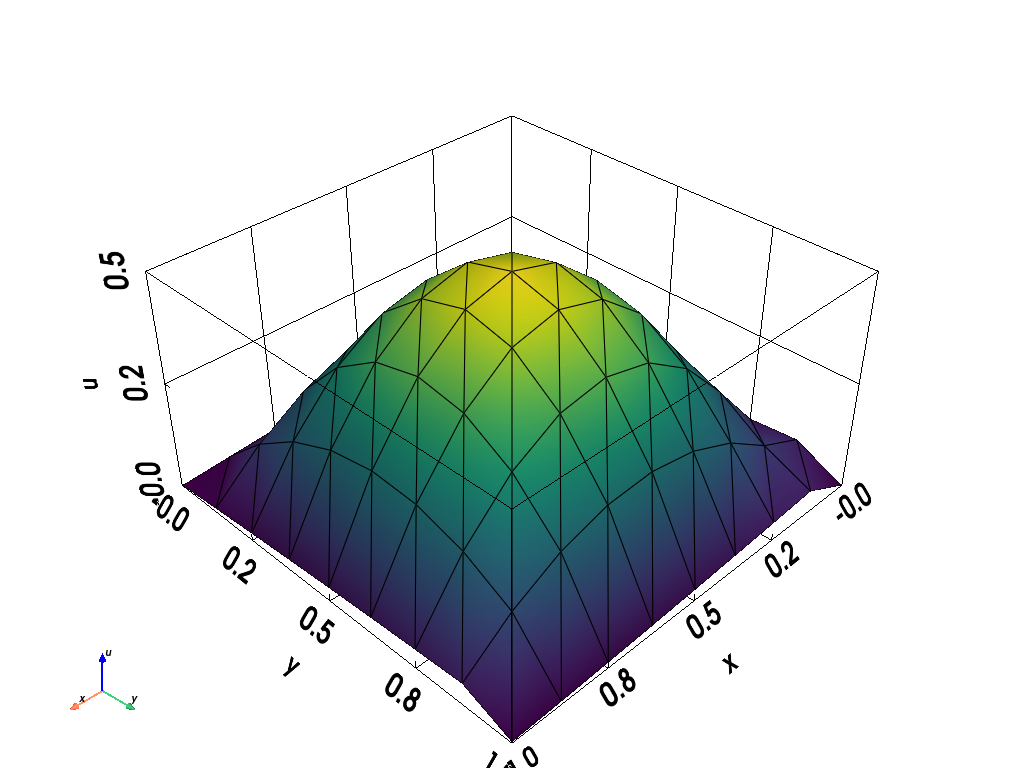

In [7]:
# Crouzeix-Raviart

# Fix MPI/OFI finalization errors on macOS
import os

os.environ["FI_PROVIDER"] = "tcp"
os.environ["MPICH_OFI_STARTUP_CONNECT"] = "0"


from mpi4py import MPI
import numpy as np
from petsc4py.PETSc import ScalarType
from dolfinx import mesh, fem, plot, io, la
from dolfinx.fem.petsc import LinearProblem
import ufl
import pyvista


# Mesh
msh = mesh.create_rectangle(
    comm=MPI.COMM_WORLD,
    points=((0.0, 0.0), (1.0, 1.0)),
    n=(8, 8),
    cell_type=mesh.CellType.triangle,
)

# Function space
V = fem.functionspace(msh, ("CR", 1))
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)


# Dicichlet boundary conditions
def marker(x):
    return (
        np.isclose(x[0], 0.0)
        | np.isclose(x[1], 0.0)
        | np.isclose(x[0], 1.0)
        | np.isclose(x[1], 1.0)
    )

facets = mesh.locate_entities_boundary(msh, dim=(msh.topology.dim - 1), marker=marker)
dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)


# RHS function
x = ufl.SpatialCoordinate(msh)
f = 2.0 * (x[0] * (1.0 - x[0]) + x[1] * (1.0 - x[1]))
D = 1
u_exact = x[0] * x[1] * (1.0 - x[0]) * (1.0 - x[1]) # known test solution (giving our corr. f)


# Variational form
a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx # stiffness matrix
L = ufl.inner(f, v) * ufl.dx # load vector

A = fem.assemble_matrix(fem.form(a))
b = fem.assemble_vector(fem.form(L))
print(A.to_dense())
print(b.array)


# Problem
problem = LinearProblem(
    a,
    L,
    bcs=[bc],
    petsc_options_prefix="test_poisson_",
    petsc_options={
        "ksp_type": "preonly",
        "pc_type": "lu",
        "ksp_errorf_not_converged": True,
    },
)

uh = problem.solve()


l2_error = np.sqrt(
    fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx))
)


print(f"Error: {l2_error}")



###############################
# Plotting with pyvista (3D)
###############################
# Interpolate CR solution to CG1 for VTK plotting
V_plot = fem.functionspace(msh, ("CG", 1))
uh_plot = fem.Function(V_plot)
uh_plot.interpolate(uh)
cells, types, x = plot.vtk_mesh(V_plot)
grid = pyvista.UnstructuredGrid(cells, types, x)
grid.point_data["u"] = uh_plot.x.array.real
grid.set_active_scalars("u")

warp_factor = 8
warped = grid.warp_by_scalar("u", factor=warp_factor)

plotter = pyvista.Plotter()
plotter.add_mesh(
    warped,
    scalars="u",
    cmap="viridis",
    show_scalar_bar=False,
    show_edges=True,
    edge_color="black",
    line_width=0.6,
    smooth_shading=True,
    lighting=True,
)
plotter.show_bounds(grid="back", location="outer", all_edges=True, xtitle="x", ytitle="y", ztitle="u", font_size=25, n_zlabels=3)
plotter.add_axes(xlabel="x", ylabel="y", zlabel="u")
plotter.view_isometric()
plotter.show()


with io.XDMFFile(msh.comm, "output/poisson.xdmf", "w") as file:
    file.write_mesh(msh)
    file.write_function(uh_plot)


In [9]:
# Convergence test for Dirichlet bcs
mesh_sizes = [8, 16, 32, 64]
hs = []
errors = []

for n_cells in mesh_sizes:
    # Mesh
    msh = mesh.create_rectangle(
        comm=MPI.COMM_WORLD,
        points=((0.0, 0.0), (1.0, 1.0)),
        n=(n_cells, n_cells),
        cell_type=mesh.CellType.triangle,
    )

    # Function space
    V = fem.functionspace(msh, ("CG", 1))
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)


    # Dicichlet boundary conditions
    def marker(x):
        return (
            np.isclose(x[0], 0.0)
            | np.isclose(x[1], 0.0)
            | np.isclose(x[0], 1.0)
            | np.isclose(x[1], 1.0)
        )

    facets = mesh.locate_entities_boundary(msh, dim=(msh.topology.dim - 1), marker=marker)
    dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
    bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)


    # RHS function
    x = ufl.SpatialCoordinate(msh)
    f = 2.0 * (x[0] * (1.0 - x[0]) + x[1] * (1.0 - x[1]))
    D = 1
    u_exact = x[0] * x[1] * (1.0 - x[0]) * (1.0 - x[1]) # known test solution (giving our corr. f)


    # Variational form
    a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx # stiffness matrix
    L = ufl.inner(f, v) * ufl.dx # load vector


    # Problem
    problem = LinearProblem(
        a,
        L,
        bcs=[bc],
        petsc_options_prefix="test_poisson_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "ksp_errorf_not_converged": True,
        },
    )

    uh = problem.solve()


    l2_error = np.sqrt(
        fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx))
    )
    
    hs.append(1.0 / n_cells)
    errors.append(l2_error)
    

if msh.comm.rank == 0:
    print("n        h        L2-error      rate")
    for i, (n_cells, h_i, e_i) in enumerate(zip(mesh_sizes, hs, errors)):
        if i == 0:
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {'-':>5}")
        else:
            rate_i = np.log(errors[i - 1] / e_i) / np.log(hs[i - 1] / h_i)
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {rate_i:>5.2f}")


n        h        L2-error      rate
8        0.1250   1.4414e-03       -
16       0.0625   3.6557e-04    1.98
32       0.0312   9.1723e-05    1.99
64       0.0156   2.2952e-05    2.00


In [4]:
# Convergence test for Crouzeix-Raviart (same Dirichlet problem)
mesh_sizes = [8, 16, 32, 64]
hs = []
errors = []

for n_cells in mesh_sizes:
    # Mesh
    msh = mesh.create_rectangle(
        comm=MPI.COMM_WORLD,
        points=((0.0, 0.0), (1.0, 1.0)),
        n=(n_cells, n_cells),
        cell_type=mesh.CellType.triangle,
    )

    # Function space
    V = fem.functionspace(msh, ("CR", 1))
    u = ufl.TrialFunction(V)
    v = ufl.TestFunction(V)


    # Dicichlet boundary conditions
    def marker(x):
        return (
            np.isclose(x[0], 0.0)
            | np.isclose(x[1], 0.0)
            | np.isclose(x[0], 1.0)
            | np.isclose(x[1], 1.0)
        )

    facets = mesh.locate_entities_boundary(msh, dim=(msh.topology.dim - 1), marker=marker)
    dofs = fem.locate_dofs_topological(V=V, entity_dim=1, entities=facets)
    bc = fem.dirichletbc(value=ScalarType(0), dofs=dofs, V=V)


    # RHS function
    x = ufl.SpatialCoordinate(msh)
    f = 2.0 * (x[0] * (1.0 - x[0]) + x[1] * (1.0 - x[1]))
    D = 1
    u_exact = x[0] * x[1] * (1.0 - x[0]) * (1.0 - x[1]) # known test solution (giving our corr. f)


    # Variational form
    a = ufl.inner(D*ufl.grad(u), ufl.grad(v)) * ufl.dx # stiffness matrix
    L = ufl.inner(f, v) * ufl.dx # load vector


    # Problem
    problem = LinearProblem(
        a,
        L,
        bcs=[bc],
        petsc_options_prefix="test_poisson_",
        petsc_options={
            "ksp_type": "preonly",
            "pc_type": "lu",
            "ksp_errorf_not_converged": True,
        },
    )

    uh = problem.solve()


    l2_error = np.sqrt(
        fem.assemble_scalar(fem.form(ufl.inner(uh - u_exact, uh - u_exact) * ufl.dx))
    )
    
    hs.append(1.0 / n_cells)
    errors.append(l2_error)
    

if msh.comm.rank == 0:
    print("n        h        L2-error      rate")
    for i, (n_cells, h_i, e_i) in enumerate(zip(mesh_sizes, hs, errors)):
        if i == 0:
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {'-':>5}")
        else:
            rate_i = np.log(errors[i - 1] / e_i) / np.log(hs[i - 1] / h_i)
            print(f"{n_cells:<6d} {h_i:>8.4f}   {e_i:>10.4e}   {rate_i:>5.2f}")

n        h        L2-error      rate
8        0.1250   6.1192e-04       -
16       0.0625   1.5504e-04    1.98
32       0.0312   3.8895e-05    2.00
64       0.0156   9.7322e-06    2.00
